# Abstract

The purpose of this notebook is to review some code to be used to analyze the Wisconsin Case Study. This case is described in the book [Constructing Insurable Risk Portfolios](https://users.ssc.wisc.edu/~ewfrees/InsurableRisks/).

In particular, it is introduced in Section 1.2, further described in Section 6.3.3, with porfolios developed Section 8.1.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/WiscCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>





#  Getting Started - Reminder

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

Next, run the following two boxes. The first checks that we can do basic calculations. The second is an "R" command (generate 10 standard normal random variates), to make sure that "R" is working. Then, try changing the numbers so you can convince yourself that this is an interactive environment.

You can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where the libraries are needed with comments.

In [20]:
install.packages("alabama")
library(alabama)
library(ggplot2)
install.packages("gridExtra")
library(gridExtra)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Simulate Multivariate Data

The generation of the multivariate data is described in Section 8.3.4 of the book, an appendix titled *Generate Property Fund Data*. As with the ANU case, in the workshop we will simply load this forecast data.

In [21]:
#save(Prop.array,
#     file = "../Data/WiscPropFundData/SimPropArray.RData")
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/PropertyFundData/SimPropArray.RData", destfile = "SimPropArray.RData")
load(file = "SimPropArray.RData")
ls.str() # List objects with details
summary(Prop.array)

alpha :  num 0.8
bw :  num 1
cexsize :  num 3.5
ClaimTable :  num [1:6, 1:6] 0 0 55.7 298.3 581.2 ...
Coverage :  Named num [1:6] 118.77 12.5 1.59 4.95 1.59 ...
CstLevNum :  num [1:11] 0.95 0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 ...
dataout : 'data.frame':	1098 obs. of  41 variables:
 $ PolicyNum      : int  120002 120003 120004 120005 120008 120009 120010 120012 120013 120015 ...
 $ Year           : int  2011 2011 2011 2011 2011 2011 2011 2011 2011 2011 ...
 $ ClaimBC        : num  0 0 0 2124 5498 ...
 $ ClaimIM        : num  7897 147241 0 0 3292 ...
 $ ClaimPN        : num  14346 5151 26273 3006 5970 ...
 $ ClaimPO        : num  12033 4453 1849 2699 0 ...
 $ ClaimCN        : num  0 1674 1130 0 968 ...
 $ ClaimCO        : num  4557 73476 0 32558 0 ...
 $ TypeCity       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TypeCounty     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ TypeMisc       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TypeSchool     : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TypeTown       : int  0 0 0 0 0 0 0 0 0 0

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    0.00     0.00     0.00     3.59     0.00 11362.42 

# General Constrained Optimization Approach

As before, we will use the `auglag` function for general constrained optimization. It requires:

*   An objective function (`fn`) to minimize.
    *   Optionally, a gradient function for `fn` (`gr`).
*   An inequality constraint function (`hin`) where `hin(x) >= 0`.
    *   Optionally, a gradient function for `hin` (`jac_hin`).

Our problem is:

*   **Minimize**: $RM[g({\bf X}; \boldsymbol \theta)]$ (uncertainty of retained risks)
*   **Subject to**: $RTC(\boldsymbol \theta) \le RTC_{max}$ (budget constraint)
*   **Subject to**: $\theta_j \ge 0 $ for all $j$ (non-negative weights)

## Useful Functions

Here are some useful functions for the optimization

*  starting with a function `RetClaims.fct` for retained claims $g({\bf X}; \boldsymbol \theta)$
*  then, `ESKernmin.fct` computes a smoothed version of the expected shortfall objective function, described in Section 7.3,
*  `RTCR.fct` is a function to compute the risk transfer cost (based on simulation)
*  `ESSummary.fct` is a function to summarize risk measures
*  `f0z.fct` provides the gradient of the smoothed expected shortfall objective function
*  `ThetaOptim.fct` computes the frontier


Note that you need to provide starting values for this approach...

In [22]:
#install.packages("alabama")
#library(alabama)

# These functions are for ES minimization of
#  Excess of Loss (TRUE) and Quota Share (ExLoss = FALSE)

# Function to Compute Retained Claims
RetClaims.fct <- function(coeff, Xsim, ExLoss = TRUE){
  VaR.z0    <- coeff[1]
  theta.vec <- coeff[-1]
  p.num     <- length(theta.vec)
  RetClaims <- rep(0, nrow(Xsim) )
  if (ExLoss){  # Excess of Loss
     for (kidx in 1:p.num){RetClaims <- RetClaims +
                             pmin(Xsim[,kidx], theta.vec[kidx]) }
     } else {  # Quota Share
            RetClaims  <- as.vector(Xsim %*% theta.vec)   }
  return( RetClaims )
}  # end RetClaims.fct function

#  ESKernmin.fct evaluates the ES objective function
#    using kernel smoothing
ESKernmin.fct <- function(coeff, RetClaims){
  VaR.z0        <- coeff[1]
  theta.vec     <- coeff[-1]
  ESKern1.fct   <- function(ytidle) { as.numeric( mean(
                        pmax(RetClaims + bw * ytidle - VaR.z0, 0) ) ) *
                               dnorm(ytidle)  }
  ESKernmin     <- VaR.z0 + integrate(Vectorize(ESKern1.fct),
                                      lower = -6, upper = 6)$value / (1-alpha)
  return( ESKernmin )
}  # end ESKernmin.fct function

#Function to Compute Simulated RTC
RTCR.fct <- function(Xsim, RetClaims){
  CeededClaims <- rowSums(Xsim) - RetClaims
  RTC.R     <- mean( CeededClaims )
  return( RTC.R )
}  # end RTCR.fct function

# Function to Summarize Risk Measures
ESSummary.fct <- function(coeff, RetClaims){
  VaR.z0    <- coeff[1]
  theta.vec <- coeff[-1]
  ones      <- rep(1, length(RetClaims) )
  stddev    <- sd(RetClaims)
  VaR       <- as.numeric(quantile(RetClaims, prob = alpha, na.rm = TRUE))
  Kern.df   <- function(y){ yarg <- (y*ones - RetClaims)/bw
                            return(mean(pnorm(yarg)) - alpha)}
  Kern.VaR  <- uniroot(f=Kern.df,lower = VaR - 100, upper = VaR + 100)$root
  ESmin     <- as.numeric(VaR.z0 +
                            mean(pmax(RetClaims - VaR.z0, 0)) /(1-alpha) )
  ES        <- as.numeric(VaR   +
                            mean(pmax(RetClaims - VaR,   0)) /(1-alpha) )
  ESKern1.fct <- function(y) { as.numeric ( mean( pmax(
                           RetClaims -  VaR.z0 +  bw * y, 0) ) ) * dnorm(y) }
  ESKernmin   <- VaR.z0 + integrate(Vectorize(ESKern1.fct),
                                   lower = -6, upper = 6)$value / (1-alpha)
  ESKern2.fct <- function(y) { as.numeric ( mean( pmax(
                           RetClaims - Kern.VaR + bw * y, 0) ) ) * dnorm(y) }
  ESKern      <- Kern.VaR + integrate(Vectorize(ESKern2.fct), lower = -6,
                                     upper = 6)$value / (1-alpha)
  return( c(VaR, Kern.VaR, ESmin, ES,  ESKernmin, ESKern, stddev) )
}  # end ESSummary.fct function

# Gradient of the ES Objective Function
f0z.fct <- function(coeff, Xsim, RetClaims, ExLoss = TRUE){
  VaR.z0        <- coeff[1]
  theta.vec     <- coeff[-1]
  numLoss       <- nrow(Xsim)
  ones          <- rep(1, numLoss )
  VaR.z0arg     <- (VaR.z0*ones - RetClaims) / bw
  partial.z0    <- 1 - mean( 1-pnorm(VaR.z0arg) ) / (1 - alpha)

  if (ExLoss){  # Excess of Loss
              mat.check <-  t( 1* ( t(Xsim) > theta.vec) )
      } else {  # Quota Share
              mat.check <- Xsim  }
  temp          <- ( 1-pnorm(VaR.z0arg) ) %*% mat.check / numLoss
  partial.theta <- temp / (1 - alpha)
  return( c(partial.z0, partial.theta) )
  }  # end f0z.fct function

# Function to Construct a Frontier of Optimal Portfolios
#  p.z is the number of coefficients (including VaR)
ThetaOptim.fct <- function(Xsim, ExLoss = TRUE, p.z = 15,
                           RTCmax.vec, starter.coeff) {
  Output.mat <- matrix(0,nrow = length(RTCmax.vec), ncol = 1+6+p.z)
  f0.ES      <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                return(ESKernmin.fct(coeff, RetClaims) ) }
  f0.grad    <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                return(f0z.fct(coeff, Xsim, RetClaims, ExLoss) ) }
  RTC.optim  <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                                 return(RTCR.fct(Xsim,RetClaims) )}
  # Use RTCR.fct for empirical RTCs, RTC.fct for lognormal

  for (jCost in 1:length(RTCmax.vec)){    # Start jCost Loop
    hin.ES <- function(coeff) {h <- NA    # Constraints in alabama
      h[1] <- RTCmax.vec[jCost] - RTC.optim(coeff)
      for (j in 1:p.z){h[j+1] <- 1e6*coeff[j] }
      if (ExLoss==FALSE){                 # For Quota Share
        for (j in 2:p.z){h[j+p.z] <-  1e6 * (1.0 - coeff[j]) }
      }
      return(h)
      }
  if (jCost > 1 ){starter.coeff <- ES.opt$par*1.1}
    z.params <- rep(0, p.z); LME.EX <- 0
    tryCatch({
        ES.opt <- alabama::auglag( par=starter.coeff,
           fn  = f0.ES,         # objective function
           gr  = f0.grad,       # gradient objective function
           hin = hin.ES,        # constraints
           control.outer=list(method="nlminb",trace=FALSE) )
        z.params <- ES.opt$par
        LME.EX <- ES.opt$lambda[1] },
        error=function(err) {
        z.params <- starter.coeff
        LME.EX <- 0} )
    RetClaims <- RetClaims.fct(z.params, Xsim, ExLoss)
    RTCR      <- RTC.optim(z.params)
    output    <- c(RTCmax.vec[jCost], RTCR ,
                   ESSummary.fct(z.params, RetClaims)[-c(3,5)],
                   z.params[-1] , LME.EX)
    cat("Theory Results",output, "\n")
    Output.mat[jCost,] <- output
    }  # end jCost Loop
    return(Output.mat)
    }  # end ThetaOptim.fct function


#  Risk Retention for a Specific Member

This is code for Section 8.1.2  of the book.

## Descriptive Statistics

In [23]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/PropertyFundData/dataout.RData", destfile = "dataout.RData")
load(file = "dataout.RData")


In [24]:
PolNum = 2
# Coverage is in millions, not in logs
Coverage <- cbind(dataout$CoverageBC,
                  dataout$CoverageIM,
                  dataout$CoverageCN,
                  dataout$CoverageCO,
                  dataout$CoveragePN,
                  dataout$CoveragePO)
Coverage <- Coverage[PolNum,]
names(Coverage) <- c("BC", "IM", "CN", "CO", "PN", "PO")
print('Table 8.1. Six Coverage Amounts for Member 2')
print('Coverages are in millions of U.S. Dollars')
Coverage

[1] "Table 8.1. Six Coverage Amounts for Member 2"
[1] "Coverages are in millions of U.S. Dollars"


BC         IM         CN         CO         PN         PO 
118.771179  12.496976   1.592299   4.945964   1.592299   5.010964

In [25]:
SummaryOut <- Prop.array[,,PolNum]
dfSummaryOut <- data.frame(t(SummaryOut))

colnames(dfSummaryOut) <- c("BC", "IM", "CN", "CO", "PN", "PO")
fun1 = function(x) { c(ma=min(x), m1=median(x),m=mean(x),
                       mq = quantile(x, probs =0.95),
                       mb=quantile(x, probs =0.99),
                       mz = 100*mean(x)/(mean(SummaryOut)*6) ) }

# Calculate statistics for each column
t1_stats <- as.matrix(fun1(dfSummaryOut$BC))
t2_stats <- as.matrix(fun1(dfSummaryOut$IM))
t3_stats <- as.matrix(fun1(dfSummaryOut$CN))
t4_stats <- as.matrix(fun1(dfSummaryOut$CO))
t5_stats <- as.matrix(fun1(dfSummaryOut$PN))
t6_stats <- as.matrix(fun1(dfSummaryOut$PO))

# Combine the results into ClaimTable
ClaimTable <- cbind(t1_stats, t2_stats, t3_stats, t4_stats, t5_stats, t6_stats)

rownames(ClaimTable) <- c("Minimum", "Median", "Mean","95th Percentile",
                          "99th Percentile", "Mean Percent of Total")
colnames(ClaimTable) <-  c("BC", "IM", "CN", "CO", "PN", "PO")
print('Forecast Loss Distribution for Member 2')
print('Losses are in thousands of U.S. Dollars.')
round(ClaimTable, digits = 3)

[1] "Forecast Loss Distribution for Member 2"
[1] "Losses are in thousands of U.S. Dollars."


,BC,IM,CN,CO,PN,PO
Minimum,0.000,0.000,0.000,0.000,0.000,0.000
Median,0.000,0.000,5.466,4.482,3.251,0.000
Mean,55.750,10.834,14.660,23.905,8.138,5.772
95th Percentile,298.255,64.627,57.090,102.963,30.993,31.000
99th Percentile,581.208,118.658,91.546,168.225,48.789,56.127
Mean Percent of Total,46.826,9.100,12.313,20.078,6.835,4.848


## Frontier

Here is some code for multiple runs of the optimization to create a frontier.

In [26]:
# Section812ES
# This code utilizes the 'ThetaOptim.fct' and 'ESSummary.fct'
#   functions, introduced in Section 7.4
#   See 'ConstructPortFunctionsMar2024.Rmd'

PolNum = 2
#load(file = "../Data/WiscPropFundData/SimPropArray.RData")
Xsim <- t(Prop.array[,,PolNum])

TotCostProp2    <- mean (rowSums(Xsim))
CstLevNum       <- 1 - c(0.05, seq(0.1, 0.9, length.out=9),0.95)
CstLevNum       <- round(CstLevNum*100)/100
Prop2RTCmax.vec <- TotCostProp2 * CstLevNum

#  A Few Key Parameters
bw            <- 1
alpha         <- 0.80
starter.coeff <- c(10, rep(0.1, 6) )

Time1 <- Sys.time()
OutMatProp2.ES <- ThetaOptim.fct(Xsim, ExLoss = TRUE, p.z = 7,
                                 RTCmax.vec=Prop2RTCmax.vec, starter.coeff)
Sys.time() - Time1   #Time difference of 1.663976 mins alpha = 0.80

u.names <- paste("u",1:6, sep="")
colnames(OutMatProp2.ES) <- c("RTCmax", "RTC", "VaR", "Kern.VaR", "ES",
                            "ESKern", "StdDev",  u.names ,"LME")

NaivePort.1 <- c(0, 1e10, rep(0,5))
RetNaive.1 <- RetClaims.fct(NaivePort.1, Xsim, ExLoss = TRUE)
NaivePort1Out <- c(RTCR.fct(Xsim, RetNaive.1),ESSummary.fct(RetNaive.1, Xsim)[c(1,4,7)])

names(NaivePort1Out) <-   c("RTC", "VaR", "ES", "StdDev" )
NaivePort.2   <- c(0,  0,  rep(100,5))
RetNaive.2 <- RetClaims.fct(NaivePort.2, Xsim, ExLoss = TRUE)
NaivePort2Out <- c(RTCR.fct(Xsim, RetNaive.2),ESSummary.fct(RetNaive.2, Xsim)[c(1,4,7)])
names(NaivePort2Out) <-   c("RTC", "VaR", "ES", "StdDev" )

Theory Results 113.1052 113.1052 9.63567 9.835118 10.83921 11.05014 3.732356 1.625234 0.517221 4.07599 2.283709 2.59667 0.1620792 1.84343 
Theory Results 107.1523 107.1523 19.55833 19.73453 22.4436 22.52835 7.689552 4.062676 1.794566 7.184237 5.709097 4.758127 0.7170437 1.995362 
Theory Results 95.24646 95.24646 39.98265 40.05121 47.62155 47.65484 16.41877 12.2893 5.269261 12.7289 12.75324 8.652111 2.754493 2.221453 
Theory Results 83.34065 83.34065 60.83248 61.10637 75.27794 75.30632 26.26507 23.21792 12.14901 18.49936 19.10964 12.04306 6.391821 2.419931 
Theory Results 71.43485 71.43485 82.72763 82.76874 105.3222 105.3352 37.31242 37.11956 20.69326 26.28914 26.32175 15.50668 9.727252 2.62936 
Theory Results 59.52904 59.52904 104.4262 104.6233 137.7656 137.7778 49.63116 54.15796 33.92554 35.56109 34.84409 18.49076 14.30045 2.820899 
Theory Results 47.62323 47.62323 127.697 127.8715 173.2965 173.3043 63.50576 76.47651 51.21611 44.97881 46.55087 23.16006 20.58487 3.147111 
Theory Result

Time difference of 1.363616 mins

In [27]:
numVarsPrint <- 6
riskTypes  <- c("BC", "IM", "CN", "CO", "PN", "PO")
uPrint.names <- paste("u",riskTypes, sep=".")

#OutMatPrint <- OutMatProp2.ES[,1:(5+numVarsPrint)]
OutMatPrint <- OutMatProp2.ES[,c(1,2,3,5, 7, 8:13)]
OutMatPrint <- round(OutMatPrint, digits = 1)
OutMatPrint[,1:2] <- round(OutMatPrint[,1:2], digits = 0)

colnames(OutMatPrint) <- c("$RTC_{max}$", "$RTC$", "$VaR$", "$ES$",
                           "Std Dev",
                           "$u_{BC}$", "$u_{IM}$", "$u_{CN}$",
                           "$u_{CO}$", "$u_{PN}$", "$u_{PO}$" )
print('Table 8.3. Fund Member 2 Excess of Loss Frontier')
round(OutMatPrint, digits = 1)

[1] "Table 8.3. Fund Member 2 Excess of Loss Frontier"


$RTC_{max}$,$RTC$,$VaR$,$ES$,Std Dev,$u_{BC}$,$u_{IM}$,$u_{CN}$,$u_{CO}$,$u_{PN}$,$u_{PO}$
113,113,9.6,10.8,3.7,1.6,0.5,4.1,2.3,2.6,0.2
107,107,19.6,22.4,7.7,4.1,1.8,7.2,5.7,4.8,0.7
95,95,40.0,47.6,16.4,12.3,5.3,12.7,12.8,8.7,2.8
83,83,60.8,75.3,26.3,23.2,12.1,18.5,19.1,12.0,6.4
71,71,82.7,105.3,37.3,37.1,20.7,26.3,26.3,15.5,9.7
60,60,104.4,137.8,49.6,54.2,33.9,35.6,34.8,18.5,14.3
48,48,127.7,173.3,63.5,76.5,51.2,45.0,46.6,23.2,20.6
36,36,150.4,213.1,79.4,105.7,67.8,60.7,67.2,31.7,28.2
24,24,175.7,258.1,98.3,151.7,112.3,80.9,97.0,48.1,45.4
12,12,193.3,313.7,121.6,245.8,175.0,152.1,171.7,82.4,96.0


## Visualizing the Frontier

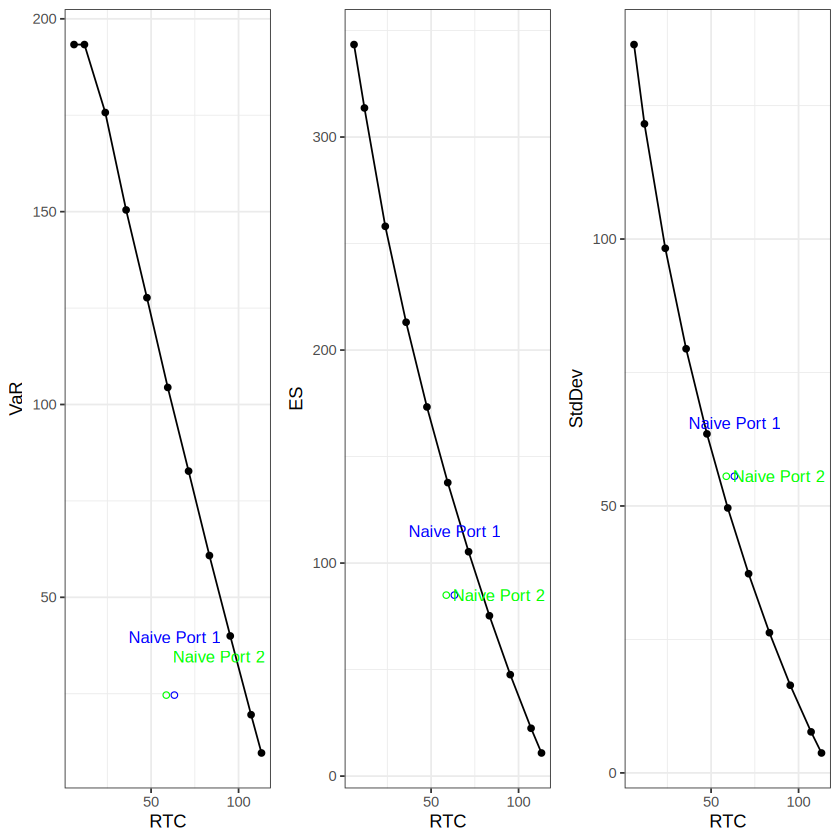

In [28]:
FigRed    = "red"        ;  FigBlue   = "blue"
FigGreen  = "green"      ;  FigLBlue  = "lightblue"
FigDBlue  = "darkblue"   ;  FigDGreen = "darkgreen"
FigLGreen = "lightgreen" ;  FigOrange = "orange"

rndfac <- 50
cexsize <- 3.5
dfPlot <- data.frame(OutMatProp2.ES)
p1 <- ggplot(dfPlot, aes(x=RTC, y=VaR)) + geom_point() + theme_bw() +
          scale_x_continuous(breaks = seq(from = rndfac*round(min(dfPlot$RTC)/rndfac),
                                          to = rndfac*round(max(dfPlot$RTC)/rndfac),
                                          length.out = 3))+geom_line() +
annotate("point", x=NaivePort1Out[1], y=NaivePort1Out[2], colour=FigBlue, shape=1)+
annotate("text", x=NaivePort1Out[1], y=NaivePort1Out[2]+15, label="Naive Port 1",
          colour = FigBlue, cex = cexsize )+
annotate("point", x=NaivePort2Out[1], y=NaivePort2Out[2], colour=FigGreen, shape=1)+
annotate("text", x=NaivePort2Out[1]+30, y=NaivePort2Out[2]+10, label="Naive Port 2",
          colour = FigGreen, cex = cexsize )
p2 <- ggplot(dfPlot, aes(x=RTC, y=ES)) + geom_point() + theme_bw() +
          scale_x_continuous(breaks = seq(from = rndfac*round(min(dfPlot$RTC)/rndfac),
                                          to = rndfac*round(max(dfPlot$RTC)/rndfac),
                                          length.out = 3))+geom_line() + labs(y = 'ES') +
annotate("point", x=NaivePort1Out[1], y=NaivePort1Out[3], colour=FigBlue, shape=1)+
annotate("text", x=NaivePort1Out[1], y=NaivePort1Out[3]+30, label="Naive Port 1",
          colour = FigBlue, cex = cexsize )+
annotate("point", x=NaivePort2Out[1], y=NaivePort2Out[3], colour=FigGreen, shape=1)+
annotate("text", x=NaivePort2Out[1]+30, y=NaivePort2Out[3], label="Naive Port 2",
          colour = FigGreen, cex = cexsize )

p3 <- ggplot(dfPlot, aes(x=RTC, y=StdDev)) + geom_point() + theme_bw() +
          scale_x_continuous(breaks = seq(from = rndfac*round(min(dfPlot$RTC)/rndfac),
                                          to = rndfac*round(max(dfPlot$RTC)/rndfac),
                                          length.out = 3))+geom_line() +
annotate("point", x=NaivePort1Out[1], y=NaivePort1Out[4], colour=FigBlue, shape=1) +
annotate("text", x=NaivePort1Out[1], y=NaivePort1Out[4]+10, label="Naive Port 1",
          colour = FigBlue, cex = cexsize )+
annotate("point", x=NaivePort2Out[1], y=NaivePort2Out[4], colour=FigGreen, shape=1)+
annotate("text", x=NaivePort2Out[1]+30, y=NaivePort2Out[4], label="Naive Port 2",
          colour = FigGreen, cex = cexsize )
grid.arrange(p1,p2,p3,nrow=1)

If you have time, you can check out Section 8.1 of the book for additional analyses.